成功读入图像: cityroad.png, 尺寸: (600, 267), 模式: RGB
正在进行 Sobel 卷积计算...
正在生成可视化图像...


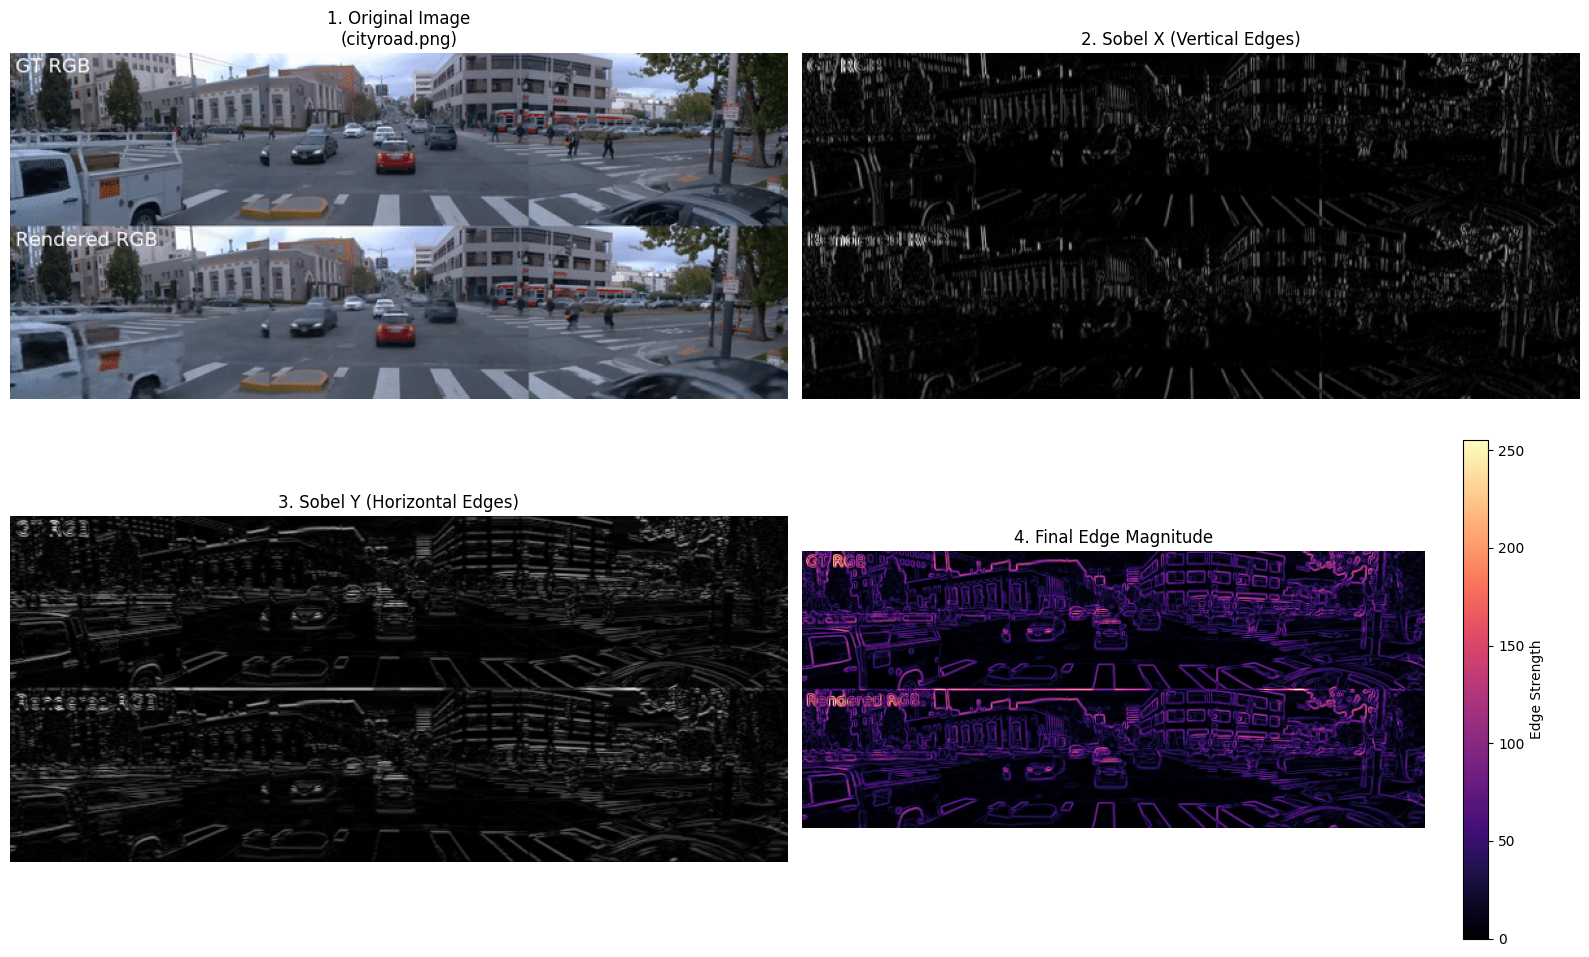

处理完成。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d
import os

# ==========================================
# 1. 设置：请在此处修改你的图片路径
# ==========================================
# 示例：'C:/Users/Name/Pictures/my_photo.jpg' 或 './my_photo.png'
IMAGE_PATH = 'cityroad.png' # <-- 替换这里

def load_and_preprocess_image(path):
    """
    读入图片，检查是否存在，并转为灰度浮点数矩阵
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件: {path}，请检查路径是否正确。")
    
    # 读入图像
    with Image.open(path) as pil_img:
        print(f"成功读入图像: {path}, 尺寸: {pil_img.size}, 模式: {pil_img.mode}")
        
        # 将彩色图像转为灰度图 ('L' 模式)
        # 这是边缘检测的标准预处理步骤
        gray_img = pil_img.convert('L')
        
        # 转为 Numpy 数组，并转换为 float32 方便计算
        img_array = np.array(gray_img, dtype=np.float32)
        
        # 保留原图用于显示 (转回 RGB 方便 Matplotlib 显示彩色)
        original_rgb = pil_img.convert('RGB')
        
    return img_array, original_rgb

def apply_sobel_filter(gray_img):
    """
    核心部分：使用 Scipy 实现二维 Sobel 卷积操作
    """
    # 定义 Sobel 算子 (保留上一节的滤波器)
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]])

    sobel_y = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]])

    print("正在进行 Sobel 卷积计算...")
    # 执行二维卷积
    # boundary='symm' 处理边缘填充，mode='same' 保持图像尺寸不变
    gx = convolve2d(gray_img, sobel_x, mode='same', boundary='symm')
    gy = convolve2d(gray_img, sobel_y, mode='same', boundary='symm')

    # 计算梯度幅值 (Magnitude)
    magnitude = np.sqrt(gx**2 + gy**2)

    # 归一化：将结果映射到 0-255 之间
    if magnitude.max() > 0:
        magnitude = (magnitude / magnitude.max()) * 255
    
    return magnitude.astype(np.uint8), gx, gy

# ==========================================
# 主程序执行流
# ==========================================
try:
    # 1. 加载和预处理
    gray_data, original_display = load_and_preprocess_image(IMAGE_PATH)

    # 2. 应用 Sobel 滤波器
    edge_magnitude, grad_x, grad_y = apply_sobel_filter(gray_data)

    # 3. 可视化结果
    print("正在生成可视化图像...")
    plt.figure(figsize=(16, 10))

    # A. 原始彩色图
    plt.subplot(2, 2, 1)
    plt.title(f"1. Original Image\n({IMAGE_PATH})")
    plt.imshow(original_display)
    plt.axis('off')

    # B. 水平梯度 (检测垂直边缘) - 显示绝对值
    plt.subplot(2, 2, 2)
    plt.title("2. Sobel X (Vertical Edges)")
    plt.imshow(np.abs(grad_x), cmap='gray')
    plt.axis('off')

    # C. 垂直梯度 (检测水平边缘) - 显示绝对值
    plt.subplot(2, 2, 3)
    plt.title("3. Sobel Y (Horizontal Edges)")
    plt.imshow(np.abs(grad_y), cmap='gray')
    plt.axis('off')

    # D. 最终边缘幅值
    plt.subplot(2, 2, 4)
    plt.title("4. Final Edge Magnitude")
    # 使用 'viridis' 或 'magma' 等色调可以更好地观察边缘强度差别
    plt.imshow(edge_magnitude, cmap='magma') 
    plt.colorbar(label='Edge Strength')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    print("处理完成。")

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"发生错误: {e}")